In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,KFold, cross_val_score

# Data Loading

In [2]:
df = pd.read_csv('D:/Projects/End-to-End/Model/ai_jobs_market_2025_2026.csv')
pd.set_option('display.max_columns', None)
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [3]:
df.nunique()

job_id                   1500
job_title                  25
job_category               12
experience_level            4
years_of_experience        15
education_required          5
annual_salary_usd         248
salary_min_usd             17
salary_max_usd             16
city                       20
country                    14
remote_work                 3
company_size                5
industry                   12
required_skills          1500
ai_salary_premium_pct     151
demand_score               20
demand_growth_yoy_pct     565
benefits_score_10          39
posting_year                2
posting_month              12
is_senior                   2
is_remote_friendly          2
is_llm_role                 2
salary_tier                 5
dtype: int64

In [4]:
df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [5]:
df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


# Feature Engineering

In [6]:
for col in df.columns:
    if df[col].dtype == 'str':
        print(f"Unique values in '{col}': {df[col].unique()}\n\n")
        df[col] = df[col].apply(lambda x: x.lower())

Unique values in 'job_id': <StringArray>
['AIJOB0001', 'AIJOB0002', 'AIJOB0003', 'AIJOB0004', 'AIJOB0005', 'AIJOB0006',
 'AIJOB0007', 'AIJOB0008', 'AIJOB0009', 'AIJOB0010',
 ...
 'AIJOB1491', 'AIJOB1492', 'AIJOB1493', 'AIJOB1494', 'AIJOB1495', 'AIJOB1496',
 'AIJOB1497', 'AIJOB1498', 'AIJOB1499', 'AIJOB1500']
Length: 1500, dtype: str


Unique values in 'job_title': <StringArray>
[      'AI Agent Developer',          'Prompt Engineer',
             'LLM Engineer',       'Data Engineer (AI)',
       'AI Product Manager',     'AI Security Engineer',
       'Senior ML Engineer',             'NLP Engineer',
   'AI Solutions Architect',              'ML Engineer',
   'Generative AI Engineer',   'Deep Learning Engineer',
   'Multimodal AI Engineer',           'MLOps Engineer',
      'AI Business Analyst',             'RAG Engineer',
   'Robotics Engineer (AI)',    'Senior Data Scientist',
        'AI Ethics Officer',    'AI Infrastructure Eng',
              'AI Engineer',           'Data Scie

In [30]:
# Dropping this columns to avoid {target leakage}
df_reg = df.drop(columns=['job_id', 'salary_min_usd', 'salary_max_usd', 'salary_tier','city', 'required_skills'])
df_reg.head()

,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,country,remote_work,company_size,industry,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
0,ai agent developer,ai engineering,senior (6-9 yrs),7,master's,239000.0,usa,on-site,startup (1-50),finance,13.1,96,16.9,6.8,2026,3,1,0,1
1,prompt engineer,ai engineering,senior (6-9 yrs),2,bachelor's,166000.0,uk,hybrid,enterprise (5000+),finance,5.4,82,11.6,6.2,2026,1,1,1,1
2,llm engineer,ai engineering,senior (6-9 yrs),4,associate's,360000.0,usa,fully remote,big tech (faang+),finance,9.1,98,42.7,7.7,2026,1,1,1,1
3,data engineer (ai),data engineering,senior (6-9 yrs),3,bachelor's,161000.0,singapore,fully remote,sme (51-500),technology,12.0,88,6.7,9.5,2026,3,1,1,0
4,ai product manager,product,lead (10+ yrs),5,bootcamp/self-taught,283000.0,usa,fully remote,enterprise (5000+),automotive,9.4,85,17.3,8.9,2026,1,1,1,0


In [31]:
df_reg.columns

Index(['job_title', 'job_category', 'experience_level', 'years_of_experience',
       'education_required', 'annual_salary_usd', 'country', 'remote_work',
       'company_size', 'industry', 'ai_salary_premium_pct', 'demand_score',
       'demand_growth_yoy_pct', 'benefits_score_10', 'posting_year',
       'posting_month', 'is_senior', 'is_remote_friendly', 'is_llm_role'],
      dtype='str')

In [32]:
def expbucket(x):
    if x <= 2:
        return 'junior'
    elif x <= 5 and x > 2:
        return 'mid'
    elif x <= 10 and x > 5:
        return 'senior'
    else:
        return 'lead'
    
def encode_remote(x):
    if 'remote' in x.lower():
        return 1
    else:
        return 0

# Use label encoder for ordinal features or for output (only in classification)
exp_order = {'junior': 0, 'mid': 1, 'senior': 2, 'lead': 3}
edu_order = {'bootcamp/self-taught': 0, 'associate': 1, 'bachelor': 2, 'master': 3, 'phd': 4}
company_size_order = {'startup': 0, 'sme': 1, 'mid': 2, 'big': 4, 'enterprise': 3}

df_reg['bucket_of_experience'] = df_reg['years_of_experience'].apply(expbucket)
df_reg['experience_level'] = df_reg['experience_level'].apply(lambda x: x.split(' ')[0])
df_reg['company_size'] = df_reg['company_size'].apply(lambda x: x.split(' ')[0])
df_reg['remote_work'] = df_reg['remote_work'].apply(encode_remote)
df_reg['education_required'] = df_reg['education_required'].apply(lambda x: x.split("'")[0])
df_reg['bucket_of_experience'] = df_reg['bucket_of_experience'].map(exp_order)
df_reg['experience_level'] = df_reg['experience_level'].map(exp_order).fillna(0)
df_reg['education_required'] = df_reg['education_required'].map(edu_order).fillna(0)
df_reg['company_size'] = df_reg['company_size'].map(company_size_order)

df_reg.head()

,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,country,remote_work,company_size,industry,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,bucket_of_experience
0,ai agent developer,ai engineering,2.0,7,3,239000.0,usa,0,0.0,finance,13.1,96,16.9,6.8,2026,3,1,0,1,2
1,prompt engineer,ai engineering,2.0,2,2,166000.0,uk,0,3.0,finance,5.4,82,11.6,6.2,2026,1,1,1,1,0
2,llm engineer,ai engineering,2.0,4,1,360000.0,usa,1,4.0,finance,9.1,98,42.7,7.7,2026,1,1,1,1,1
3,data engineer (ai),data engineering,2.0,3,2,161000.0,singapore,1,1.0,technology,12.0,88,6.7,9.5,2026,3,1,1,0,1
4,ai product manager,product,3.0,5,0,283000.0,usa,1,3.0,automotive,9.4,85,17.3,8.9,2026,1,1,1,0,1


In [33]:
encode_categories = OneHotEncoder(handle_unknown="ignore")
str_cols = df_reg.select_dtypes(include=['object', 'str']).columns
# for col in df_reg.columns:
#     if df_reg[col].dtype == 'str':


encoded = encode_categories.fit_transform(df_reg[str_cols])
df_reg = pd.concat([df_reg, pd.DataFrame(encoded.toarray(), columns=encode_categories.get_feature_names_out(str_cols))], axis=1)
df_reg.drop(columns=str_cols, inplace=True)
df_reg.head()
# print(str_cols)

,experience_level,years_of_experience,education_required,annual_salary_usd,remote_work,company_size,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,bucket_of_experience,job_title_ai agent developer,job_title_ai business analyst,job_title_ai compliance manager,job_title_ai engineer,job_title_ai ethics officer,job_title_ai infrastructure eng,job_title_ai product manager,job_title_ai research scientist,job_title_ai security engineer,job_title_ai solutions architect,job_title_computer vision engineer,job_title_data engineer (ai),job_title_data scientist,job_title_deep learning engineer,job_title_generative ai engineer,job_title_llm engineer,job_title_ml engineer,job_title_mlops engineer,job_title_multimodal ai engineer,job_title_nlp engineer,job_title_prompt engineer,job_title_rag engineer,job_title_robotics engineer (ai),job_title_senior data scientist,job_title_senior ml engineer,job_category_ai engineering,job_category_architecture,job_category_business,job_category_data engineering,job_category_data science,job_category_governance,job_category_infrastructure,job_category_ml operations,job_category_product,job_category_research,job_category_robotics,job_category_security,country_australia,country_canada,country_china,country_france,country_germany,country_global,country_india,country_japan,country_netherlands,country_singapore,country_switzerland,country_uae,country_uk,country_usa,industry_automotive,industry_consulting,industry_education,industry_energy,industry_finance,industry_government,industry_healthcare,industry_manufacturing,industry_media,industry_research,industry_retail,industry_technology
0,2.0,7,3,239000.0,0,0.0,13.1,96,16.9,6.8,2026,3,1,0,1,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,2,2,166000.0,0,3.0,5.4,82,11.6,6.2,2026,1,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,4,1,360000.0,1,4.0,9.1,98,42.7,7.7,2026,1,1,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.0,3,2,161000.0,1,1.0,12.0,88,6.7,9.5,2026,3,1,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,5,0,283000.0,1,3.0,9.4,85,17.3,8.9,2026,1,1,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
with open('OneHotEncoder_categories.pkl', 'wb') as f:
    pickle.dump(encode_categories, f)

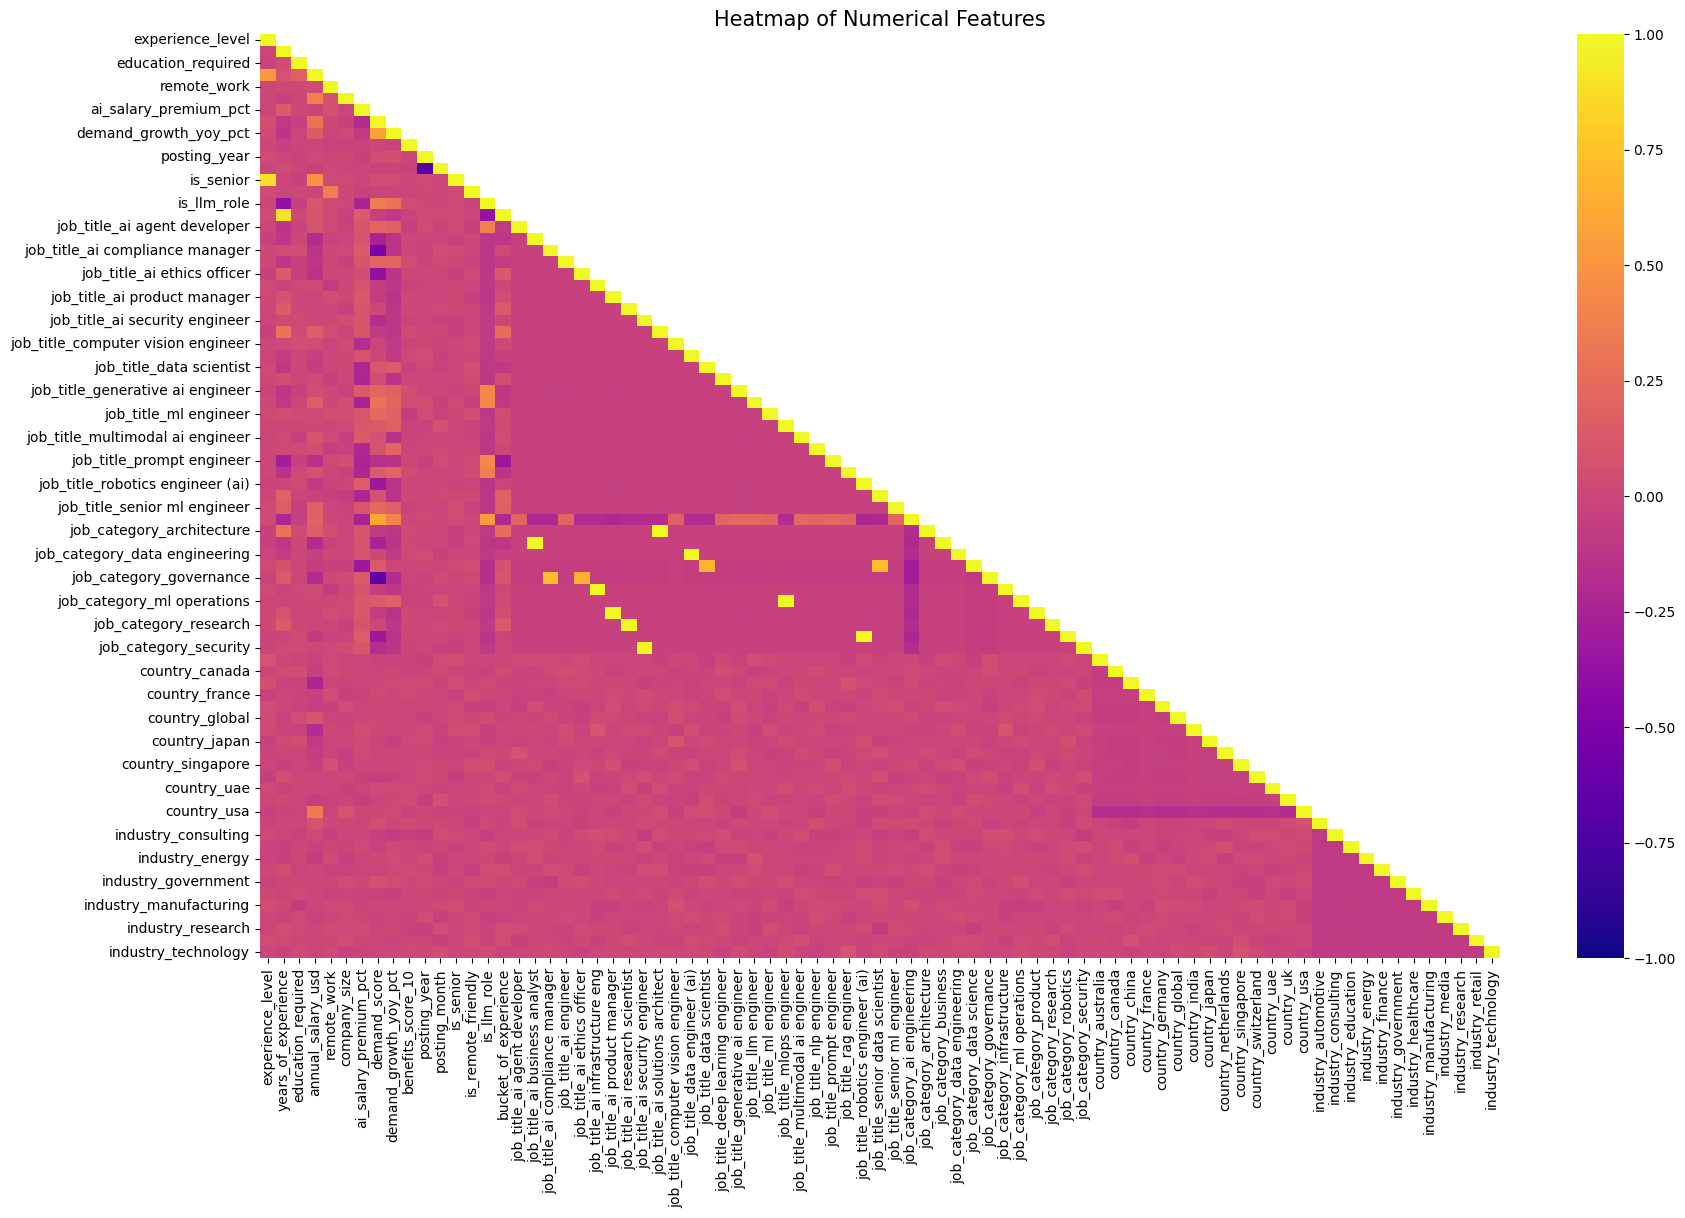

In [35]:
cor =df_reg.corr()
plt.figure(figsize=(20,12))
mask = np.triu(np.ones_like(cor, dtype=bool))
np.fill_diagonal(mask, False)
sns.heatmap(cor, mask=mask, vmin=-1, vmax=1, cmap='plasma')
plt.title("Heatmap of Numerical Features", fontsize=15)
plt.show()

# Model Training

In [36]:
y = df_reg['annual_salary_usd']
x = df_reg.drop(columns=['annual_salary_usd'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [37]:
print(max(y_train), min(y_train))
print(max(y_test), min(y_test))

384000.0 90000.0
374400.0 90000.0


In [38]:
test_df = x_test.copy()
test_df["annual_salary_usd"] = y_test

test_df.to_csv("test.csv", index=False)

In [39]:
xgb_regressor = XGBRegressor(random_state=42)
xgb_regressor.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [40]:
y_pred = xgb_regressor.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 534809904.39789206
R^2 Score: 0.8695260928890558


## Hyper-Parameter tuning

In [41]:


param_distributions = {
    'model__n_estimators': [200, 300, 500, 700],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_alpha': [0, 0.1, 0.5, 1],
    'model__reg_lambda': [1, 1.5, 2, 3]
}

search = RandomizedSearchCV(
    estimator=xgb_regressor,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train, y_train)

print("Best CV MSE:", search.best_score_)
print("Best Params:", search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV MSE: -591441940.3282745
Best Params: {'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.5, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


d:\Projects\End-to-End\eteenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:48:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__reg_alpha", "model__reg_lambda", "model__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
best_model = search.best_estimator_
y_pred = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
cv_scores = cross_val_score(best_model, x, y, cv=5, scoring="r2", n_jobs=-1)

print(f"Test MSE: {mse:.2f}")
print(f"Test R2: {r2:.4f}")
print(f"CV R2 Mean: {cv_scores.mean():.4f}")
print(f"CV R2 Std: {cv_scores.std():.4f}")

joblib.dump(best_model, "xgb_salary_pipeline_best.pkl")
print("Saved: xgb_salary_pipeline_best.pkl")


Test MSE: 534809904.40
Test R2: 0.8695
CV R2 Mean: 0.8850
CV R2 Std: 0.0201
Saved: xgb_salary_pipeline_best.pkl
